In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "tatarstan_economic_data_clean.csv"
)

df = pd.read_csv(PROCESSED_DATA_PATH)
df.head()

,year,unemployment_rate,investment_index,average_salary,housing_price,grp_mln_rub,working_age_population_thousands,unemployment_diff,investment_diff,grp_log_growth,salary_log_growth,housing_price_log_growth
0,2000,12.1,124.8,2180.0,2850.0,168590.0,2655.0,NaN,NaN,NaN,NaN,NaN
1,2001,10.8,118.6,1850.0,3210.0,194230.0,2662.0,-1.3,-6.2,0.141573,-0.164139,0.118952
2,2002,9.6,115.4,3560.0,3680.0,223450.0,2670.0,-1.2,-3.2,0.140145,0.654575,0.136642
3,2003,8.4,120.2,4420.0,4150.0,261870.0,2675.0,-1.2,4.8,0.158661,0.216379,0.120196
4,2004,7.5,126.7,5580.0,4890.0,312450.0,2680.0,-0.9,6.5,0.176596,0.233049,0.164084


In [2]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isna().sum())

Shape: (26, 12)

Columns:
['year', 'unemployment_rate', 'investment_index', 'average_salary', 'housing_price', 'grp_mln_rub', 'working_age_population_thousands', 'unemployment_diff', 'investment_diff', 'grp_log_growth', 'salary_log_growth', 'housing_price_log_growth']

Data types:
year                                  int64
unemployment_rate                   float64
investment_index                    float64
average_salary                      float64
housing_price                       float64
grp_mln_rub                         float64
working_age_population_thousands    float64
unemployment_diff                   float64
investment_diff                     float64
grp_log_growth                      float64
salary_log_growth                   float64
housing_price_log_growth            float64
dtype: object

Missing values:
year                                0
unemployment_rate                   0
investment_index                    0
average_salary                      0
housing

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,26.0,2.012500e+03,7.648529,2000.000000,2006.250000,2.012500e+03,2.018750e+03,2.025000e+03
unemployment_rate,26.0,5.199423e+00,2.775667,1.725000,3.362500,4.050000e+00,6.775000e+00,1.210000e+01
investment_index,26.0,1.111106e+02,11.865625,86.400000,104.706250,1.113500e+02,1.199250e+02,1.303000e+02
average_salary,26.0,2.902654e+04,23461.033940,1850.000000,9197.500000,2.507875e+04,4.361000e+04,8.340000e+04
housing_price,26.0,5.154328e+04,53217.330963,2850.000000,7152.500000,4.390751e+04,6.424077e+04,1.934250e+05
grp_mln_rub,26.0,1.025152e+06,627674.780193,168590.000000,480195.000000,1.048785e+06,1.441648e+06,2.250000e+06
working_age_population_thousands,24.0,2.523458e+03,154.731178,2240.000000,2382.500000,2.582500e+03,2.659000e+03,2.680000e+03
unemployment_diff,25.0,-4.150000e-01,0.656084,-1.625000,-0.900000,-3.000000e-01,-1.500000e-01,1.700000e+00
investment_diff,25.0,-7.790000e-01,11.527069,-26.200000,-6.200000,5.750000e-01,5.675000e+00,2.655000e+01
grp_log_growth,25.0,1.036486e-01,0.069534,-0.040735,0.060511,8.950196e-02,1.680878e-01,2.028203e-01


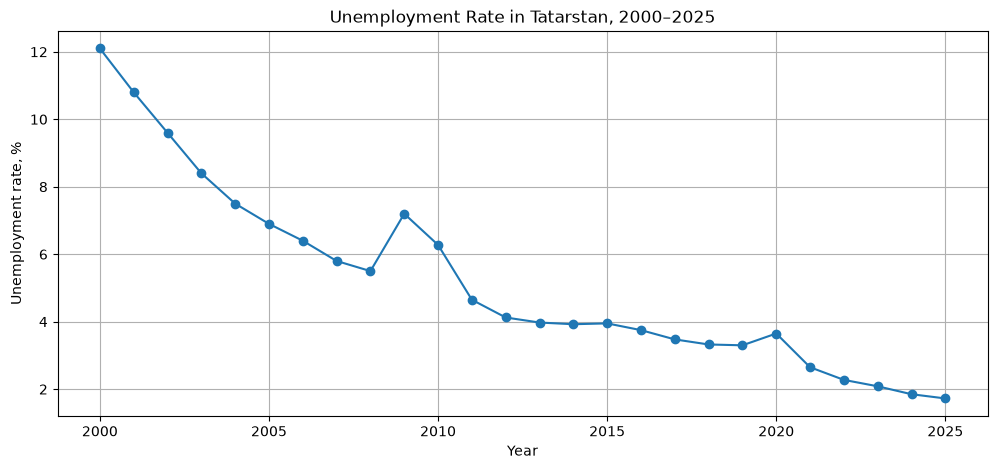

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(
    df["year"],
    df["unemployment_rate"],
    marker="o"
)
plt.title("Unemployment Rate in Tatarstan, 2000–2025")
plt.xlabel("Year")
plt.ylabel("Unemployment rate, %")
plt.grid(True)

plt.show()

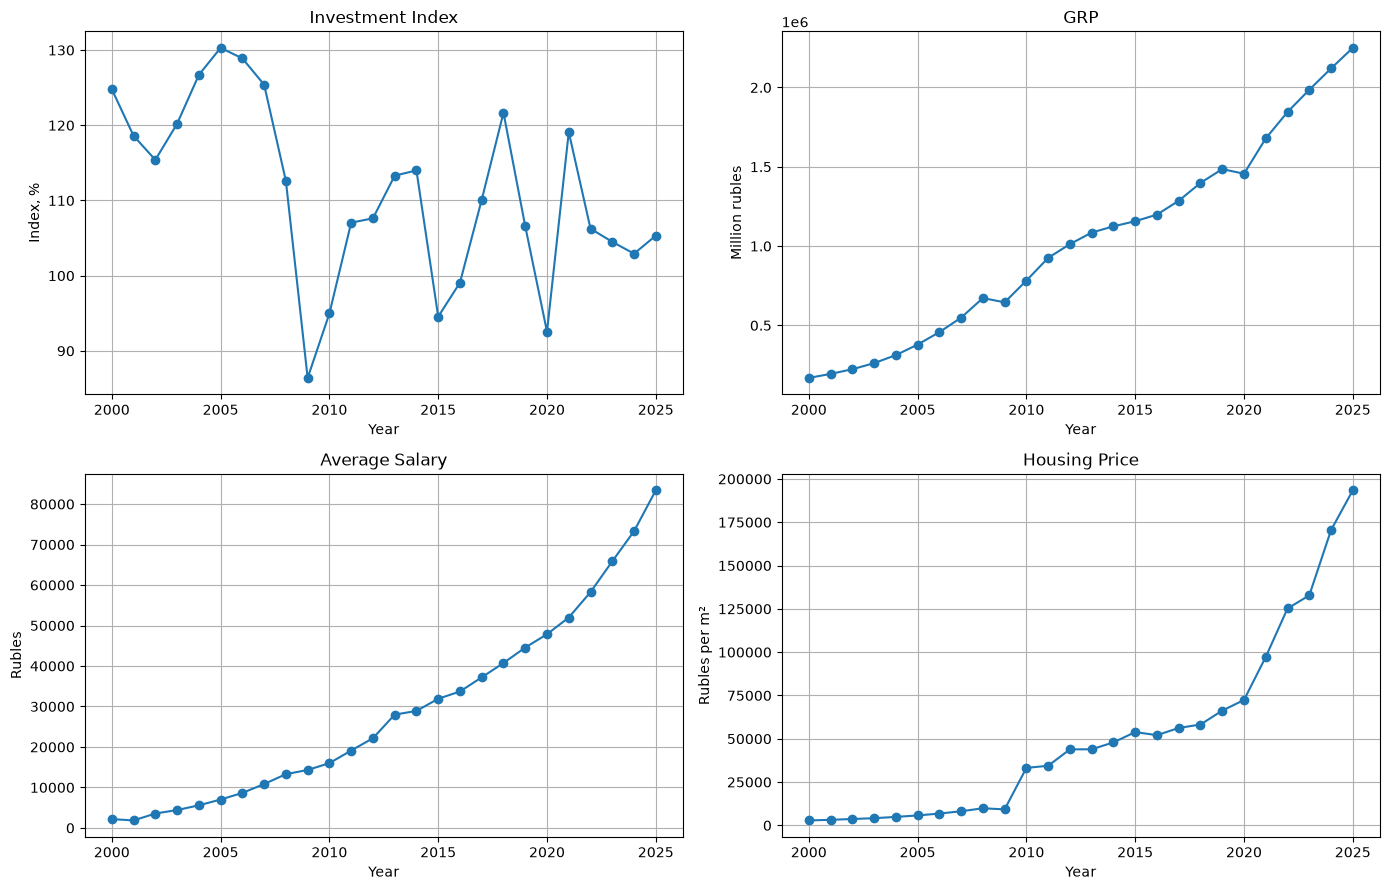

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes[0, 0].plot(
    df["year"],
    df["investment_index"],
    marker="o"
)

axes[0, 0].set_title("Investment Index")
axes[0, 0].set_xlabel("Year")
axes[0, 0].set_ylabel("Index, %")
axes[0, 0].grid(True)

axes[0, 1].plot(
    df["year"],
    df["grp_mln_rub"],
    marker="o"
)

axes[0, 1].set_title("GRP")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Million rubles")
axes[0, 1].grid(True)

axes[1, 0].plot(
    df["year"],
    df["average_salary"],
    marker="o"
)

axes[1, 0].set_title("Average Salary")
axes[1, 0].set_xlabel("Year")
axes[1, 0].set_ylabel("Rubles")
axes[1, 0].grid(True)

axes[1, 1].plot(
    df["year"],
    df["housing_price"],
    marker="o"
)

axes[1, 1].set_title("Housing Price")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("Rubles per m²")
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

In [7]:
correlation_columns = [
    "unemployment_rate",
    "investment_index",
    "average_salary",
    "housing_price",
    "grp_mln_rub"
]

correlation_matrix = df[correlation_columns].corr()
correlation_matrix

,unemployment_rate,investment_index,average_salary,housing_price,grp_mln_rub
unemployment_rate,1.000000,0.407453,-0.853870,-0.779918,-0.908873
investment_index,0.407453,1.000000,-0.429675,-0.386091,-0.466917
average_salary,-0.853870,-0.429675,1.000000,0.976520,0.987820
housing_price,-0.779918,-0.386091,0.976520,1.000000,0.950505
grp_mln_rub,-0.908873,-0.466917,0.987820,0.950505,1.000000


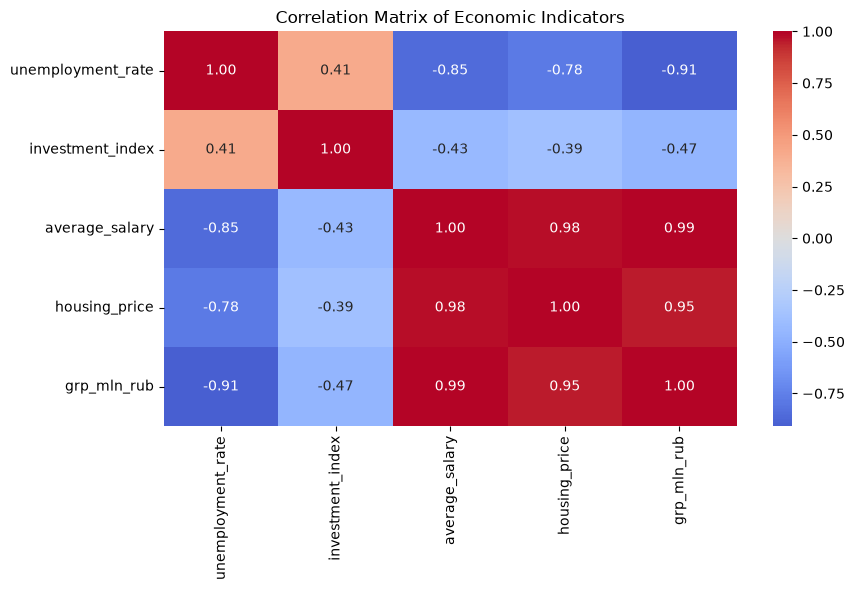

In [8]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Economic Indicators")
plt.tight_layout()
plt.show()

In [9]:
change_columns = [
    "unemployment_diff",
    "investment_diff",
    "grp_log_growth",
    "salary_log_growth",
    "housing_price_log_growth"
]
change_correlation = df[change_columns].corr()
change_correlation

,unemployment_diff,investment_diff,grp_log_growth,salary_log_growth,housing_price_log_growth
unemployment_diff,1.000000,-0.598403,-0.773891,-0.261293,-0.296592
investment_diff,-0.598403,1.000000,0.427274,0.073671,0.209745
grp_log_growth,-0.773891,0.427274,1.000000,0.353115,0.416346
salary_log_growth,-0.261293,0.073671,0.353115,1.000000,-0.005219
housing_price_log_growth,-0.296592,0.209745,0.416346,-0.005219,1.000000


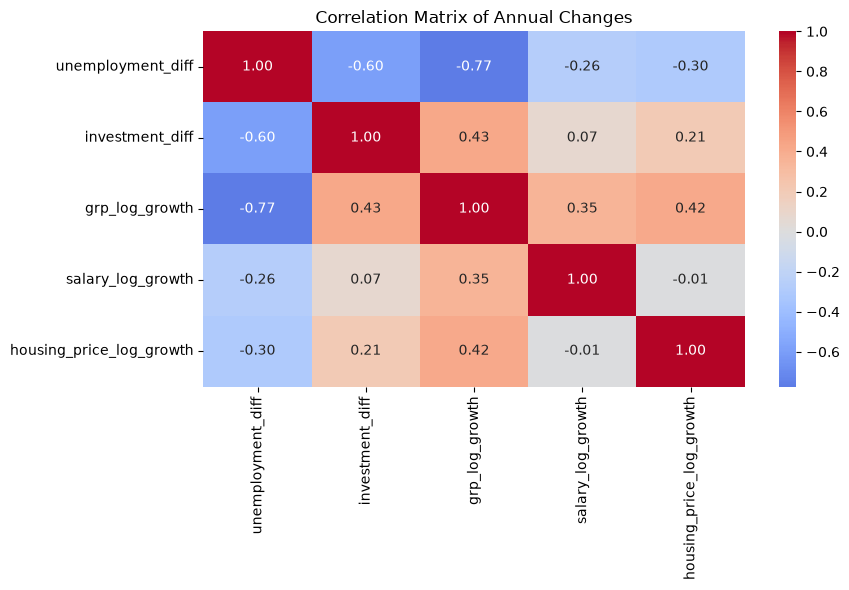

In [10]:
plt.figure(figsize=(9, 6))
sns.heatmap(
    change_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Annual Changes")
plt.tight_layout()
plt.show()

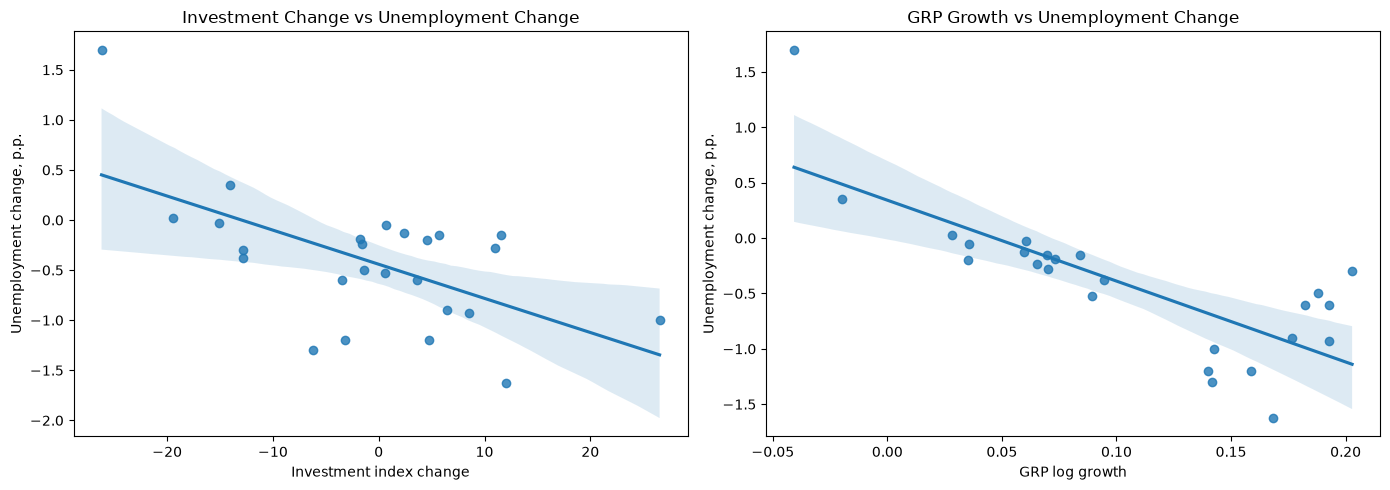

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(
    data=df,
    x="investment_diff",
    y="unemployment_diff",
    ax=axes[0]
)

axes[0].set_title("Investment Change vs Unemployment Change")
axes[0].set_xlabel("Investment index change")
axes[0].set_ylabel("Unemployment change, p.p.")

sns.regplot(
    data=df,
    x="grp_log_growth",
    y="unemployment_diff",
    ax=axes[1]
)

axes[1].set_title("GRP Growth vs Unemployment Change")
axes[1].set_xlabel("GRP log growth")
axes[1].set_ylabel("Unemployment change, p.p.")

plt.tight_layout()
plt.show()

The unemployment rate shows a long-term downward trend over 2000–2025.
Raw economic indicators contain strong time trends and high correlations.
Annual changes and log growth rates were therefore used for further analysis.
Unemployment changes are negatively associated with investment changes and GRP growth.
GRP growth and investment change were selected as the main predictors for further modeling.

- Уровень безработицы демонстрирует долгосрочную тенденцию к снижению в период с 2000 по 2025 год. 
- Сырые экономические показатели имеют ярко выраженные временные тренды и высокую корреляцию. 
- Поэтому для дальнейшего анализа использовались годовые изменения и логарифмические темпы роста. 
- Изменения уровня безработицы отрицательно коррелируют с изменениями объема инвестиций и ростом ВВП. 
- Рост ВВП и изменение объема инвестиций были выбраны в качестве основных предикторов для дальнейшего моделирования.